# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [5]:
#Which key car data drive customers to spend more money can be identified through multi variable data regression modeling to determine the largest drivers and create a predictive model based on findings.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
#First I would upload the data and run analytic python commands to understand the dataframe structure (column and row sizes)
#I would then read through all the column headings to form hypotheses on which data would most likely drive pricing decisons
#I would identify any possible additional data I may need


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.optimize import minimize
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn import set_config
set_config(display="diagram") #setting this will display your pipelines as seen above
from random import shuffle, seed
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from scipy.linalg import svd
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn import linear_model
from category_encoders import TargetEncoder

In [3]:
#Import Raw Data
cars = pd.read_csv('/Users/brianplace/Git/assignment11_1_starter/data/vehicles.csv')

In [4]:
#Get to know the data
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
#look at correlation between price and other numeric fields
correlation_matrix = cars.corr(numeric_only=True)
print(correlation_matrix)

                id     price      year  odometer
id        1.000000 -0.002779 -0.059040  0.010721
price    -0.002779  1.000000 -0.004925  0.010032
year     -0.059040 -0.004925  1.000000 -0.157215
odometer  0.010721  0.010032 -0.157215  1.000000


In [6]:
#I believe Year, Odometer, Condition would be drivers of price.
#Discover what data is in important looking fields with .value_counts()

counts_condition = cars['condition'].value_counts()
counts_condition

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

In [7]:
pd.set_option("display.max_rows", None)
counts_year = cars['year'].value_counts()
print(counts_year)

year
2017.0    36420
2018.0    36369
2015.0    31538
2013.0    30794
2016.0    30434
2014.0    30283
2019.0    25375
2012.0    23898
2011.0    20341
2020.0    19298
2008.0    17150
2010.0    15829
2007.0    14873
2006.0    12763
2009.0    12185
2005.0    10622
2004.0     8971
2003.0     7151
2002.0     5587
2001.0     4443
2000.0     3572
1999.0     3094
2021.0     2396
1998.0     1988
1997.0     1724
1996.0     1302
1995.0     1246
1994.0      968
1993.0      712
1992.0      626
1991.0      608
1990.0      599
1989.0      571
1987.0      532
1988.0      528
1986.0      523
1985.0      469
1968.0      425
1966.0      424
1969.0      409
1972.0      409
1984.0      387
1979.0      387
1965.0      365
1967.0      357
1970.0      345
1978.0      345
1973.0      334
1971.0      312
1974.0      280
1977.0      273
1980.0      272
1964.0      270
1983.0      257
1976.0      242
1963.0      234
1955.0      226
1982.0      217
1981.0      214
1975.0      204
1957.0      174
1956.0      160
196

In [8]:
counts_title_status = cars['title_status'].value_counts()
counts_title_status

title_status
clean         405117
rebuilt         7219
salvage         3868
lien            1422
missing          814
parts only       198
Name: count, dtype: int64

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [9]:
#First I would understand how the data is structured (interger, float, missing data...) to identify any data cleansing or transformation I would need to do
#I would also determine if there is any data that is not critical to the analysis or future model
#I would look deeper into the data through some descriptive statisics i.e. df.describe()

In [10]:
cars.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [11]:
cars.tail()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


In [12]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [13]:
#Price is going to be one of the most important fields therefore I am going to remove records where the price is zero $0
# Filter to exclude rows where price is 0
cars_priceonly = cars[cars['price'] != 0]
cars_priceonly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393985 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            393985 non-null  int64  
 1   region        393985 non-null  object 
 2   price         393985 non-null  int64  
 3   year          392812 non-null  float64
 4   manufacturer  377800 non-null  object 
 5   model         389284 non-null  object 
 6   condition     242596 non-null  object 
 7   cylinders     233575 non-null  object 
 8   fuel          391391 non-null  object 
 9   odometer      391695 non-null  float64
 10  title_status  386251 non-null  object 
 11  transmission  392162 non-null  object 
 12  VIN           241827 non-null  object 
 13  drive         273731 non-null  object 
 14  size          111052 non-null  object 
 15  type          308053 non-null  object 
 16  paint_color   276836 non-null  object 
 17  state         393985 non-null  object 
dtypes: float6

In [14]:
#VIN is going to be important to ensure no duplicate records therefore I will only keep data with a VIN
cars_VINonly = (cars_priceonly.dropna(subset=['VIN']))
cars_VINonly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241827 entries, 27 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            241827 non-null  int64  
 1   region        241827 non-null  object 
 2   price         241827 non-null  int64  
 3   year          240716 non-null  float64
 4   manufacturer  234562 non-null  object 
 5   model         240493 non-null  object 
 6   condition     144628 non-null  object 
 7   cylinders     134689 non-null  object 
 8   fuel          239347 non-null  object 
 9   odometer      240684 non-null  float64
 10  title_status  234220 non-null  object 
 11  transmission  240071 non-null  object 
 12  VIN           241827 non-null  object 
 13  drive         176012 non-null  object 
 14  size          46191 non-null   object 
 15  type          216898 non-null  object 
 16  paint_color   182142 non-null  object 
 17  state         241827 non-null  object 
dtypes: float

In [15]:
#Keep one unique VIN record with the highest odometer reading which would be the latest price
unique_vins_highest_odo = (
    cars_VINonly
    .sort_values(by='odometer', ascending=False)
    .drop_duplicates(subset='VIN', keep='first')
)
unique_vins_highest_odo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105811 entries, 103798 to 424638
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            105811 non-null  int64  
 1   region        105811 non-null  object 
 2   price         105811 non-null  int64  
 3   year          105228 non-null  float64
 4   manufacturer  102905 non-null  object 
 5   model         105295 non-null  object 
 6   condition     56829 non-null   object 
 7   cylinders     64884 non-null   object 
 8   fuel          104462 non-null  object 
 9   odometer      105132 non-null  float64
 10  title_status  102524 non-null  object 
 11  transmission  104907 non-null  object 
 12  VIN           105811 non-null  object 
 13  drive         82200 non-null   object 
 14  size          27379 non-null   object 
 15  type          91691 non-null   object 
 16  paint_color   79900 non-null   object 
 17  state         105811 non-null  object 
dtypes: f

In [16]:
#I want to focus my modeling on predicting prices of cars that are newer therefore I am going to drop records that have a car year less than 1995 by indexing the data
#First I need to transform the data in the year field to a datetime
#I also feel condition is important so I am going to drop records where condition is blank in the dataset drop.na from my data set

unique_vins_highest_odo['year'] = unique_vins_highest_odo['year'].astype('Int64')

cars95 = unique_vins_highest_odo[unique_vins_highest_odo['year'] >= 1995]
cars95.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103562 entries, 355243 to 424638
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            103562 non-null  int64  
 1   region        103562 non-null  object 
 2   price         103562 non-null  int64  
 3   year          103562 non-null  Int64  
 4   manufacturer  101475 non-null  object 
 5   model         103085 non-null  object 
 6   condition     55562 non-null   object 
 7   cylinders     62970 non-null   object 
 8   fuel          102296 non-null  object 
 9   odometer      102891 non-null  float64
 10  title_status  100406 non-null  object 
 11  transmission  102670 non-null  object 
 12  VIN           103562 non-null  object 
 13  drive         80501 non-null   object 
 14  size          26532 non-null   object 
 15  type          89831 non-null   object 
 16  paint_color   78012 non-null   object 
 17  state         103562 non-null  object 
dtypes: I

In [17]:
#I also feel condition is important so I am going to drop records where condition is blank in the dataset drop.na from my data set
cars95clean = (cars95.dropna(subset=['condition']))
cars95clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55562 entries, 355243 to 380066
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            55562 non-null  int64  
 1   region        55562 non-null  object 
 2   price         55562 non-null  int64  
 3   year          55562 non-null  Int64  
 4   manufacturer  54165 non-null  object 
 5   model         55382 non-null  object 
 6   condition     55562 non-null  object 
 7   cylinders     41737 non-null  object 
 8   fuel          55557 non-null  object 
 9   odometer      55394 non-null  float64
 10  title_status  53298 non-null  object 
 11  transmission  55548 non-null  object 
 12  VIN           55562 non-null  object 
 13  drive         45472 non-null  object 
 14  size          22795 non-null  object 
 15  type          51187 non-null  object 
 16  paint_color   44648 non-null  object 
 17  state         55562 non-null  object 
dtypes: Int64(1), float64(1), 

In [18]:
#Transform Odometer into an Int64
cars95clean['odometer'] = cars95clean['odometer'].astype('Int64')

In [19]:
cars95clean.tail()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
225174,7302166795,billings,13500,2013,gmc,yukon xl,excellent,8 cylinders,gas,<NA>,clean,automatic,1GKS2KE78DR346047,4wd,NaN,SUV,black,mt
280435,7316383393,syracuse,7995,2011,dodge,durango,good,6 cylinders,gas,<NA>,clean,automatic,1D4RE4GG6BC743964,4wd,full-size,SUV,white,ny
358732,7316728300,nashville,7950,2008,honda,pilot limited,excellent,NaN,gas,<NA>,rebuilt,automatic,5FNYF28768B010091,fwd,NaN,NaN,NaN,tn
358733,7316727996,nashville,12450,2018,subaru,legacy,excellent,NaN,gas,<NA>,rebuilt,automatic,4S3BNAB63J3034872,NaN,NaN,NaN,NaN,tn
380066,7316706729,san antonio,40995,2017,lexus,gx,excellent,8 cylinders,gas,<NA>,clean,automatic,JTJJM7FXXH5161909,4wd,mid-size,SUV,silver,tx


In [20]:
counts_mfg = cars95clean['manufacturer'].value_counts()
counts_mfg

manufacturer
ford               7908
chevrolet          6357
toyota             4874
honda              3445
nissan             2921
jeep               2336
bmw                2119
gmc                1846
mercedes-benz      1728
dodge              1688
hyundai            1684
subaru             1682
ram                1634
kia                1377
volkswagen         1360
lexus              1297
audi               1157
cadillac           1045
chrysler            947
mazda               855
acura               801
buick               789
infiniti            705
lincoln             570
volvo               529
mitsubishi          457
mini                401
rover               320
pontiac             261
porsche             225
jaguar              205
saturn              150
mercury             135
fiat                122
alfa-romeo          102
tesla                99
harley-davidson      20
ferrari               9
aston-martin          3
land rover            2
Name: count, dtype: int64

In [21]:
!pip install category_encoders

In [22]:
#I want to see if the manufacturer is a driver for price but I need to encode the manufacturer into a numeric value
#Using Target Encoder technique to assign a numeric value to manufacturer by using each category's mean price
# 1. Calculate the mean price for each manufacturer (Target Encoding)
# This creates a mapping dictionary: {'Buick': 14891.509506, 'Ford': 18478.518968, etc...
manufacturer_means = cars95clean.groupby('manufacturer')['price'].mean()

# 3. Append the encoded column back to the original DataFrame
# The map() function matches the manufacturer name in 'df' to the index in 'manufacturer_means'
cars95clean['manufacturer_encoded'] = cars95clean['manufacturer'].map(manufacturer_means)

cars95clean.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,manufacturer_encoded
355243,7311420685,knoxville,2650,1999,buick,regal gse,good,6 cylinders,gas,9999999,clean,automatic,2G4WF5217X1621015,fwd,NaN,sedan,black,tn,14891.509506
235716,7313894932,fayetteville,7495,2009,ford,crown victoria police,good,8 cylinders,gas,2711913,clean,automatic,2FAHP71V19X137776,NaN,NaN,NaN,NaN,nc,18478.518968
76874,7316145485,denver,2995,1999,audi,a4,good,6 cylinders,gas,2319010,clean,automatic,WAUED28D8XA297114,4wd,compact,sedan,grey,co,22444.312014
75267,7302643606,colorado springs,4995,2006,volvo,s60 t5,good,NaN,gas,2006330,clean,automatic,YV1RS547362524790,fwd,mid-size,sedan,silver,co,17385.671078
391670,7315985542,harrisonburg,2250,2003,ford,explorer xlt 4wd,good,4 cylinders,gas,1795320,clean,automatic,1FMZU73K13UA22700,4wd,full-size,SUV,red,va,18478.518968


In [23]:
#I want to see if some states have higher pricing than otherws but I need to encode the manufacturer into a numeric value
#Using Target Encoder technique to assign a numeric value to state by using each category's mean price
# 1. Calculate the mean price for each state (Target Encoding)
# This creates a mapping dictionary: {'MI': 14891.509506, 'Ford': 18478.518968, etc...
state_means = cars95clean.groupby('state')['price'].mean()

# 3. Append the encoded column back to the original DataFrame
# The map() function matches the manufacturer name in 'df' to the index in 'manufacturer_means'
cars95clean['state_encoded'] = cars95clean['state'].map(state_means)

cars95clean.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,manufacturer_encoded,state_encoded
355243,7311420685,knoxville,2650,1999,buick,regal gse,good,6 cylinders,gas,9999999,clean,automatic,2G4WF5217X1621015,fwd,NaN,sedan,black,tn,14891.509506,19990.620556
235716,7313894932,fayetteville,7495,2009,ford,crown victoria police,good,8 cylinders,gas,2711913,clean,automatic,2FAHP71V19X137776,NaN,NaN,NaN,NaN,nc,18478.518968,16610.724621
76874,7316145485,denver,2995,1999,audi,a4,good,6 cylinders,gas,2319010,clean,automatic,WAUED28D8XA297114,4wd,compact,sedan,grey,co,22444.312014,17844.736102
75267,7302643606,colorado springs,4995,2006,volvo,s60 t5,good,NaN,gas,2006330,clean,automatic,YV1RS547362524790,fwd,mid-size,sedan,silver,co,17385.671078,17844.736102
391670,7315985542,harrisonburg,2250,2003,ford,explorer xlt 4wd,good,4 cylinders,gas,1795320,clean,automatic,1FMZU73K13UA22700,4wd,full-size,SUV,red,va,18478.518968,12530.001732


In [24]:
cars95clean.describe()

,id,price,year,odometer,manufacturer_encoded,state_encoded
count,5.556200e+04,5.556200e+04,55562.0,55394.0,54165.000000,55562.000000
mean,7.311736e+09,1.981002e+04,2012.493791,95566.913619,19776.053577,19810.020482
std,4.377483e+06,5.264747e+05,5.221927,80348.566977,8466.314991,11991.260570
min,7.301584e+09,1.000000e+00,1995.0,0.0,3574.500000,12530.001732
25%,7.308345e+09,7.991000e+03,2009.0,44089.0,13390.307353,16050.705631
50%,7.313001e+09,1.399800e+04,2013.0,92049.5,18478.518968,17844.736102
75%,7.315438e+09,2.377700e+04,2017.0,133286.75,21764.814815,18771.652404
max,7.317099e+09,1.234568e+08,2022.0,9999999.0,142629.000000,82486.162803


In [25]:
#I want to see if the condition is a driver for price but I need to encode the text to numeric value by using ordinal coding such as excellent=3, fair=1, good=2, like new=4, new=5, salvage=0
mapping = {'excellent':3,'fair':1,'good':2,'like new':4,'new':5,'salvage':0,}
cars95clean['Condition Code'] = cars['condition'].map(mapping)
#Make OEM_Country and Int64
cars95clean['Condition Code'] = cars95clean['Condition Code'].astype('Int64')
cars95clean.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,transmission,VIN,drive,size,type,paint_color,state,manufacturer_encoded,state_encoded,Condition Code
355243,7311420685,knoxville,2650,1999,buick,regal gse,good,6 cylinders,gas,9999999,...,automatic,2G4WF5217X1621015,fwd,NaN,sedan,black,tn,14891.509506,19990.620556,2
235716,7313894932,fayetteville,7495,2009,ford,crown victoria police,good,8 cylinders,gas,2711913,...,automatic,2FAHP71V19X137776,NaN,NaN,NaN,NaN,nc,18478.518968,16610.724621,2
76874,7316145485,denver,2995,1999,audi,a4,good,6 cylinders,gas,2319010,...,automatic,WAUED28D8XA297114,4wd,compact,sedan,grey,co,22444.312014,17844.736102,2
75267,7302643606,colorado springs,4995,2006,volvo,s60 t5,good,NaN,gas,2006330,...,automatic,YV1RS547362524790,fwd,mid-size,sedan,silver,co,17385.671078,17844.736102,2
391670,7315985542,harrisonburg,2250,2003,ford,explorer xlt 4wd,good,4 cylinders,gas,1795320,...,automatic,1FMZU73K13UA22700,4wd,full-size,SUV,red,va,18478.518968,12530.001732,2


In [26]:
#The odometer max looks unrealistic given a search I performed that said the world record Odometer reading is only 3.25million miles therfore I am limiting my list of cars to have a max mileage range of 200k miles
#The world record for the highest vehicle mileage on a personal car is over 3.25 million miles (roughly 5.23 million km), held by Irv Gordon’s 1966 Volvo P1800S. This record, confirmed by Guinness World Records in 2013, represents the highest known odometer reading. Other high-mileage examples include a 1990 Honda Accord and various taxis surpassing 1 million miles.

In [27]:
cars95clean_200milemax = cars95clean[cars95clean['odometer'] <= 200000]
cars95clean_200milemax.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52747 entries, 393517 to 397780
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    52747 non-null  int64  
 1   region                52747 non-null  object 
 2   price                 52747 non-null  int64  
 3   year                  52747 non-null  Int64  
 4   manufacturer          51517 non-null  object 
 5   model                 52581 non-null  object 
 6   condition             52747 non-null  object 
 7   cylinders             39304 non-null  object 
 8   fuel                  52742 non-null  object 
 9   odometer              52747 non-null  Int64  
 10  title_status          50539 non-null  object 
 11  transmission          52733 non-null  object 
 12  VIN                   52747 non-null  object 
 13  drive                 42934 non-null  object 
 14  size                  21193 non-null  object 
 15  type              

In [28]:
cars95clean_200milemax.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,transmission,VIN,drive,size,type,paint_color,state,manufacturer_encoded,state_encoded,Condition Code
393517,7313797882,norfolk / hampton roads,3200,2000,toyota,camry,good,4 cylinders,gas,200000,...,automatic,4T1BG22K9YU748602,fwd,NaN,NaN,NaN,va,15293.187526,12530.001732,2
176027,7315746599,new orleans,1200,2001,jeep,grand cherokee,fair,6 cylinders,gas,200000,...,automatic,1J4GX58N61C696512,fwd,full-size,SUV,custom,la,18585.863014,18514.431718,1
407511,7316982059,seattle-tacoma,3200,2009,chrysler,t&c touring,good,6 cylinders,gas,200000,...,automatic,2A8HR54199R585021,fwd,NaN,mini-van,white,wa,11353.927138,17944.469933,2
411116,7312904536,wenatchee,3200,2004,honda,pilot,good,6 cylinders,gas,200000,...,automatic,IFTCR10A8RTA18940,4wd,mid-size,SUV,green,wa,12129.633962,17944.469933,2
418878,7307468419,kenosha-racine,2999,2010,chrysler,town & country touring,fair,6 cylinders,gas,200000,...,automatic,2A4RR8DX5AR358358,fwd,NaN,NaN,NaN,wi,11353.927138,17976.194444,1


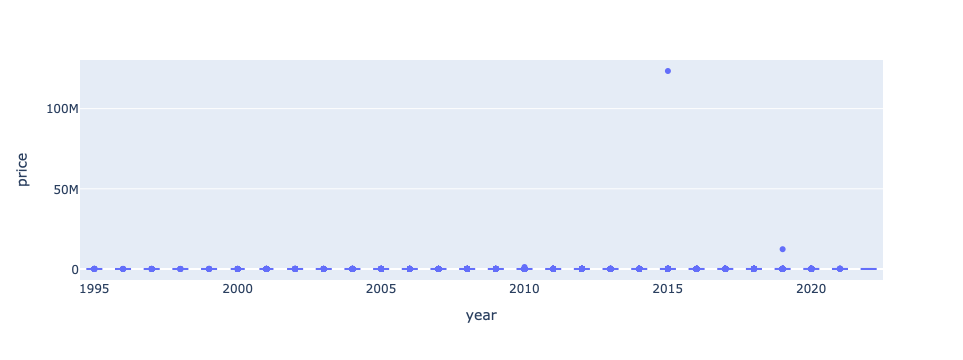

In [29]:
#Visualize Data to look for outliers on Price given above range in .describe()
px.box((cars95clean_200milemax), x='year', y='price')

In [30]:
#Putting a ceiling of $150K on price to remove outliers
cars95clean_200milemax150limit = cars95clean_200milemax[cars95clean_200milemax['price'] <= 150000]
cars95clean_200milemax150limit.describe()

,id,price,year,odometer,manufacturer_encoded,state_encoded,Condition Code
count,5.273100e+04,52731.000000,52731.0,52731.0,51509.000000,52731.000000,52731.0
mean,7.311716e+09,17721.355521,2012.805371,87416.001707,19728.850949,19801.656713,2.660276
std,4.379261e+06,12902.837716,5.060689,51396.45486,8392.946284,11943.936977,0.641243
min,7.301584e+09,1.000000,1995.0,0.0,3574.500000,12530.001732,0.0
25%,7.308326e+09,8000.000000,2010.0,41880.0,13390.307353,16050.705631,2.0
50%,7.312977e+09,14900.000000,2014.0,88300.0,18478.518968,17844.736102,3.0
75%,7.315428e+09,23995.000000,2017.0,126606.0,21764.814815,18771.652404,3.0
max,7.317099e+09,150000.000000,2022.0,200000.0,142629.000000,82486.162803,5.0


In [31]:
cars95clean_200milemax150limit.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52731 entries, 393517 to 397780
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    52731 non-null  int64  
 1   region                52731 non-null  object 
 2   price                 52731 non-null  int64  
 3   year                  52731 non-null  Int64  
 4   manufacturer          51509 non-null  object 
 5   model                 52566 non-null  object 
 6   condition             52731 non-null  object 
 7   cylinders             39292 non-null  object 
 8   fuel                  52726 non-null  object 
 9   odometer              52731 non-null  Int64  
 10  title_status          50523 non-null  object 
 11  transmission          52717 non-null  object 
 12  VIN                   52731 non-null  object 
 13  drive                 42927 non-null  object 
 14  size                  21184 non-null  object 
 15  type              

In [32]:
#Drop records that have no OEM Country
Final_Dataset = (cars95clean_200milemax150limit.dropna(subset=['manufacturer']))
Final_Dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51509 entries, 393517 to 397780
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    51509 non-null  int64  
 1   region                51509 non-null  object 
 2   price                 51509 non-null  int64  
 3   year                  51509 non-null  Int64  
 4   manufacturer          51509 non-null  object 
 5   model                 51344 non-null  object 
 6   condition             51509 non-null  object 
 7   cylinders             38344 non-null  object 
 8   fuel                  51504 non-null  object 
 9   odometer              51509 non-null  Int64  
 10  title_status          49315 non-null  object 
 11  transmission          51497 non-null  object 
 12  VIN                   51509 non-null  object 
 13  drive                 41952 non-null  object 
 14  size                  20622 non-null  object 
 15  type              

In [33]:
correlation_matrix = Final_Dataset.corr(numeric_only=True)
print(correlation_matrix)

                            id     price      year  odometer  \
id                    1.000000 -0.057273 -0.071801  0.043904   
price                -0.057273  1.000000  0.551138 -0.540101   
year                 -0.071801  0.551138  1.000000 -0.646107   
odometer              0.043904 -0.540101 -0.646107  1.000000   
manufacturer_encoded -0.025131  0.205717  0.015422 -0.004573   
state_encoded        -0.011169  0.018983  0.050978 -0.022293   
Condition Code        0.037270 -0.041051 -0.031813  0.065807   

                      manufacturer_encoded  state_encoded  Condition Code  
id                               -0.025131      -0.011169        0.037270  
price                             0.205717       0.018983       -0.041051  
year                              0.015422       0.050978       -0.031813  
odometer                         -0.004573      -0.022293        0.065807  
manufacturer_encoded              1.000000       0.031522        0.007078  
state_encoded                  

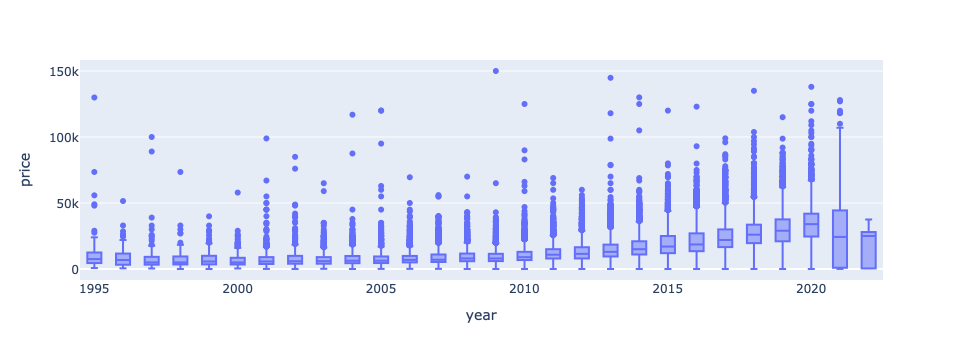

In [34]:
px.box((Final_Dataset), x='year', y='price')

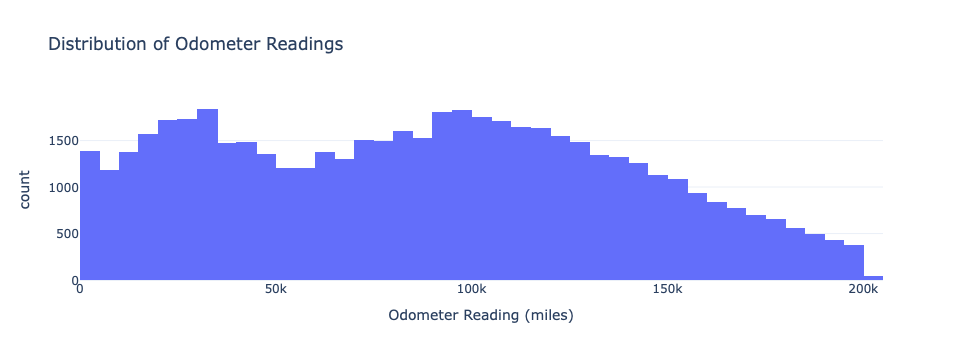

In [35]:
#Visualize Data
    
fig = px.histogram(Final_Dataset, 
                   x="odometer", 
                   title="Distribution of Odometer Readings",
                   labels={"odometer": "Odometer Reading (miles)"}, # Rename x-axis label
                   nbins=50, # Set number of bins
                   template="plotly_white") # Choose theme

fig.show()

In [36]:
#Scale Odometer given long right tail by using Robust Scaler
scaler = RobustScaler()
Final_Dataset['odometer_scaled'] = scaler.fit_transform(Final_Dataset[['odometer']])

In [37]:
Final_Dataset.describe()

,id,price,year,odometer,manufacturer_encoded,state_encoded,Condition Code,odometer_scaled
count,5.150900e+04,51509.000000,51509.0,51509.0,51509.000000,51509.000000,51509.0,51509.000000
mean,7.311717e+09,17676.950514,2012.860141,87430.670388,19728.850949,19826.348436,2.658953,-0.009513
std,4.379020e+06,12718.199007,5.030254,51332.531623,8392.946284,12002.709142,0.63982,0.606373
min,7.301584e+09,1.000000,1995.0,0.0,3574.500000,12530.001732,0.0,-1.042301
25%,7.308325e+09,8200.000000,2010.0,41908.0,13390.307353,16050.705631,2.0,-0.547257
50%,7.312977e+09,14900.000000,2014.0,88236.0,18478.518968,17844.736102,3.0,0.000000
75%,7.315430e+09,23995.000000,2017.0,126563.0,21764.814815,18771.652404,3.0,0.452743
max,7.317099e+09,150000.000000,2022.0,200000.0,142629.000000,82486.162803,5.0,1.320229


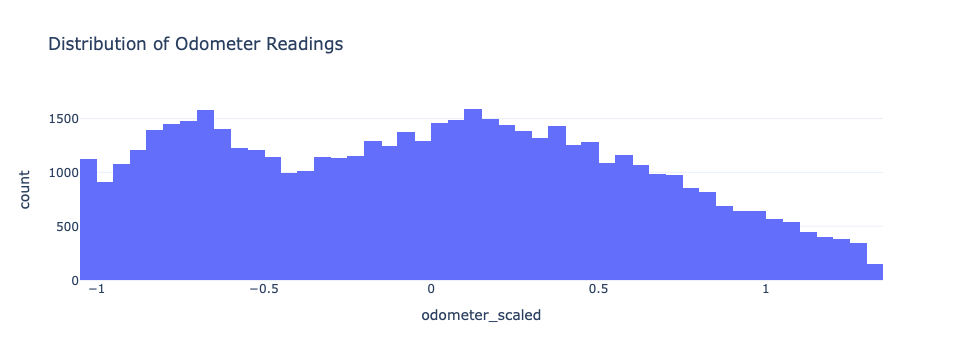

In [38]:
fig = px.histogram(Final_Dataset, 
                   x="odometer_scaled", 
                   title="Distribution of Odometer Readings",
                   labels={"odometer": "Odometer Reading (miles)"}, # Rename x-axis label
                   nbins=50, # Set number of bins
                   template="plotly_white") # Choose theme

fig.show()

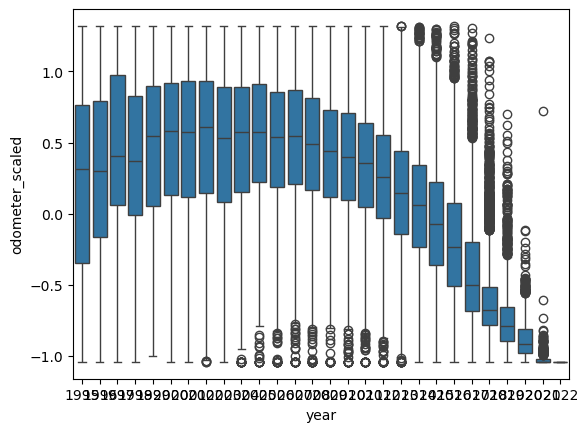

In [39]:
sns.boxplot(Final_Dataset, x="year", y="odometer_scaled")
plt.show()

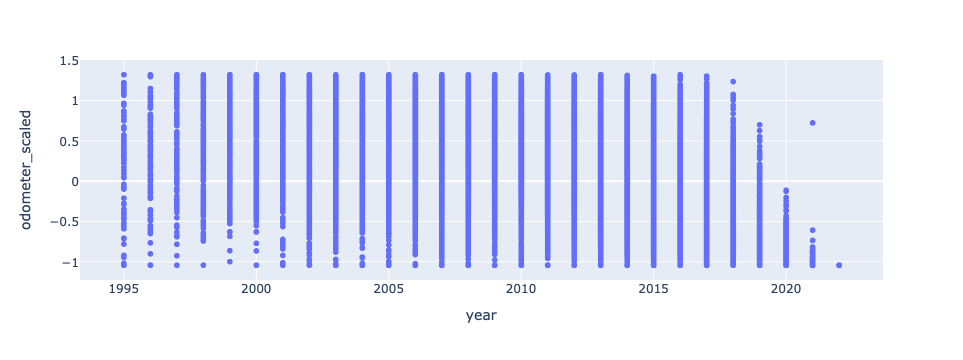

In [40]:
px.scatter((Final_Dataset), x='year', y='odometer_scaled')

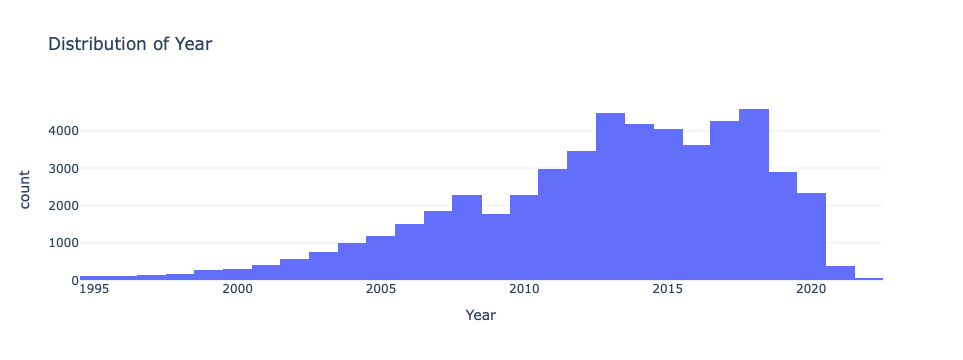

In [41]:
fig = px.histogram(Final_Dataset, 
                   x="year", 
                   title="Distribution of Year",
                   labels={"year": "Year"}, # Rename x-axis label
                   nbins=50, # Set number of bins
                   template="plotly_white") # Choose theme

fig.show()

In [42]:
#Scale Year given long left tale by using Robust Scaler
scaler = RobustScaler()
Final_Dataset['year_scaled'] = scaler.fit_transform(Final_Dataset[['year']])

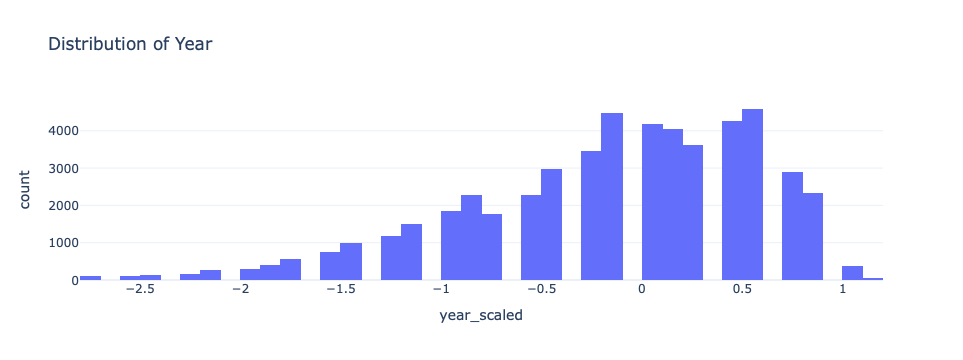

In [43]:
fig = px.histogram(Final_Dataset, 
                   x="year_scaled", 
                   title="Distribution of Year",
                   labels={"year": "Year"}, # Rename x-axis label
                   nbins=50, # Set number of bins
                   template="plotly_white") # Choose theme

fig.show()

In [44]:
#Scale Odometer given long right tale by using Robust Scaler
scaler = RobustScaler()
Final_Dataset['mfg_scaled'] = scaler.fit_transform(Final_Dataset[['manufacturer_encoded']])

In [45]:
#Scale Odometer given long right tale by using Robust Scaler
scaler = RobustScaler()
Final_Dataset['state_scaled'] = scaler.fit_transform(Final_Dataset[['state_encoded']])

In [46]:
Final_Dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51509 entries, 393517 to 397780
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    51509 non-null  int64  
 1   region                51509 non-null  object 
 2   price                 51509 non-null  int64  
 3   year                  51509 non-null  Int64  
 4   manufacturer          51509 non-null  object 
 5   model                 51344 non-null  object 
 6   condition             51509 non-null  object 
 7   cylinders             38344 non-null  object 
 8   fuel                  51504 non-null  object 
 9   odometer              51509 non-null  Int64  
 10  title_status          49315 non-null  object 
 11  transmission          51497 non-null  object 
 12  VIN                   51509 non-null  object 
 13  drive                 41952 non-null  object 
 14  size                  20622 non-null  object 
 15  type              

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [47]:
#1. Prepare Your Data
#Create a DF for SVD with numeric columns only
Final_Dataset_SVD = Final_Dataset[['odometer_scaled','year_scaled','state_scaled','Condition Code','mfg_scaled']]
Final_Dataset_SVD.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51509 entries, 393517 to 397780
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   odometer_scaled  51509 non-null  float64
 1   year_scaled      51509 non-null  float64
 2   state_scaled     51509 non-null  float64
 3   Condition Code   51509 non-null  Int64  
 4   mfg_scaled       51509 non-null  float64
dtypes: Int64(1), float64(4)
memory usage: 2.4 MB


In [48]:
# Convert data to numeric format and handle missing values
# Replace non-numeric values with NaN, then fill with mean or drop
Final_Dataset_SVD_numeric = Final_Dataset_SVD.apply(pd.to_numeric, errors='coerce')
Final_Dataset_SVD_clean = Final_Dataset_SVD_numeric.fillna(Final_Dataset_SVD_numeric.mean())
Final_Dataset_SVD_array = Final_Dataset_SVD_clean.astype(np.float64).values
scaler = StandardScaler()
Final_Dataset_SVD_scaled = scaler.fit_transform(Final_Dataset_SVD_array)

In [49]:
df_svd = pd.DataFrame(Final_Dataset_SVD_scaled, columns=[f'SVD_{i+1}' for i in range(Final_Dataset_SVD_scaled.shape[1])])
df_svd.describe()

,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5
count,5.150900e+04,51509.000000,5.150900e+04,5.150900e+04,5.150900e+04
mean,-1.412560e-16,0.000000,-1.544988e-17,-3.619686e-16,-2.758907e-19
std,1.000010e+00,1.000010,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.703238e+00,-3.550579,-6.078976e-01,-4.155822e+00,-1.924772e+00
25%,-8.868277e-01,-0.568593,-3.145689e-01,-1.029913e+00,-7.552300e-01
50%,1.568864e-02,0.226603,-1.650987e-01,5.330412e-01,-1.489756e-01
75%,7.623374e-01,0.823000,-8.787235e-02,5.330412e-01,2.425827e-01
max,2.192965e+00,1.816995,5.220523e+00,3.658950e+00,1.464341e+01


In [50]:
df_svd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51509 entries, 0 to 51508
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SVD_1   51509 non-null  float64
 1   SVD_2   51509 non-null  float64
 2   SVD_3   51509 non-null  float64
 3   SVD_4   51509 non-null  float64
 4   SVD_5   51509 non-null  float64
dtypes: float64(5)
memory usage: 2.0 MB


In [51]:
# 2. Execute the SVD
#Perform SVD to determine ideal dimentionality
U, s, VT = np.linalg.svd(Final_Dataset_SVD_array, full_matrices=False)
U, s, VT

(array([[-0.00160516,  0.00389611, -0.00260103, -0.0115407 , -0.00106371],
        [ 0.00038216,  0.00176635, -0.00067124, -0.0114467 , -0.00058309],
        [ 0.0003108 ,  0.00322293, -0.00450221, -0.00629352,  0.00777396],
        ...,
        [-0.00085529,  0.00360647, -0.00110359, -0.00010311, -0.01532101],
        [ 0.00106173,  0.0078777 , -0.00099966,  0.00824765, -0.00126406],
        [-0.00173743,  0.00230467, -0.0003776 , -0.0044677 , -0.02263603]],
       shape=(51509, 5)),
 array([1022.14987625,  610.71470423,  227.12855704,  193.59109355,
          88.48126601]),
 array([[-0.00328892, -0.00119335,  0.98867263,  0.14920781,  0.01584982],
        [ 0.0041789 , -0.06705727, -0.14961165,  0.98476485,  0.05779619],
        [-0.02374849,  0.04052115, -0.00744533, -0.05680017,  0.9972524 ],
        [-0.61110822,  0.78821587, -0.00905434,  0.05743678, -0.04337649],
        [ 0.79117285,  0.61038977, -0.00231696,  0.03807849, -0.00380938]]))

In [52]:
# Determine the number of principle components to maintain by performing SVD Singular Value Decomposition
U, s, Vt = svd(Final_Dataset_SVD_array, full_matrices=False)

Sigma =np.diag(s)
V=Vt.T

In [53]:
# 1. Convert U (Left Singular Vectors)
df_u = pd.DataFrame(U, columns=[f'U{i+1}' for i in range(U.shape[1])])

# 2. Convert s (Singular Values - usually a 1D array)
df_s = pd.DataFrame(s, columns=['SingularValues'])

# 3. Convert VT (Right Singular Vectors)
df_vt = pd.DataFrame(VT, columns=[f'Feature{i+1}' for i in range(VT.shape[1])])

In [54]:
df_u.head()


,U1,U2,U3,U4,U5
0,-0.001605,0.003896,-0.002601,-0.011541,-0.001064
1,0.000382,0.001766,-0.000671,-0.011447,-0.000583
2,0.000311,0.003223,-0.004502,-0.006294,0.007774
3,0.000313,0.003310,-0.004223,-0.009223,0.002842
4,0.000176,0.001592,-0.004227,-0.006009,0.008329


In [55]:
df_s.head()


,SingularValues
0,1022.149876
1,610.714704
2,227.128557
3,193.591094
4,88.481266


In [56]:
df_vt.head()

,Feature1,Feature2,Feature3,Feature4,Feature5
0,-0.003289,-0.001193,0.988673,0.149208,0.015850
1,0.004179,-0.067057,-0.149612,0.984765,0.057796
2,-0.023748,0.040521,-0.007445,-0.056800,0.997252
3,-0.611108,0.788216,-0.009054,0.057437,-0.043376
4,0.791173,0.610390,-0.002317,0.038078,-0.003809


In [57]:

print(df_u.shape)
print(df_s.shape)
print(df_vt.shape)

(51509, 5)
(5, 1)
(5, 5)


In [58]:
#3. Understand the Output
print("U matrix:\n", U)
print("\nSingular values (s):", s)
print("\nVT matrix:\n", VT)

U matrix:
 [[-0.00160516  0.00389611 -0.00260103 -0.0115407  -0.00106371]
 [ 0.00038216  0.00176635 -0.00067124 -0.0114467  -0.00058309]
 [ 0.0003108   0.00322293 -0.00450221 -0.00629352  0.00777396]
 ...
 [-0.00085529  0.00360647 -0.00110359 -0.00010311 -0.01532101]
 [ 0.00106173  0.0078777  -0.00099966  0.00824765 -0.00126406]
 [-0.00173743  0.00230467 -0.0003776  -0.0044677  -0.02263603]]

Singular values (s): [1022.14987625  610.71470423  227.12855704  193.59109355   88.48126601]

VT matrix:
 [[-0.00328892 -0.00119335  0.98867263  0.14920781  0.01584982]
 [ 0.0041789  -0.06705727 -0.14961165  0.98476485  0.05779619]
 [-0.02374849  0.04052115 -0.00744533 -0.05680017  0.9972524 ]
 [-0.61110822  0.78821587 -0.00905434  0.05743678 -0.04337649]
 [ 0.79117285  0.61038977 -0.00231696  0.03807849 -0.00380938]]


In [59]:
U @ Sigma @ V.T

array([[ 1.32022917e+00, -2.00000000e+00, -1.95326657e+00,
         2.00000000e+00, -3.80360452e-01],
       [ 1.32022917e+00, -1.85714286e+00,  2.46125952e-01,
         1.00000000e+00,  1.28179533e-02],
       [ 1.32022917e+00, -7.14285714e-01,  3.66540911e-02,
         2.00000000e+00, -8.50747565e-01],
       ...,
       [-1.04230110e+00, -1.00000000e+00, -1.18866390e+00,
         2.00000000e+00, -1.30496975e-01],
       [-1.04230110e+00,  8.57142857e-01,  3.40659476e-01,
         5.00000000e+00, -7.62484874e-18],
       [-1.04230110e+00, -2.00000000e+00, -1.95326657e+00,
         1.00000000e+00,  1.28179533e-02]], shape=(51509, 5))

In [60]:
Final_Dataset_SVD_array

array([[ 1.32022917, -2.        , -1.95326657,  2.        , -0.38036045],
       [ 1.32022917, -1.85714286,  0.24612595,  1.        ,  0.01281795],
       [ 1.32022917, -0.71428571,  0.03665409,  2.        , -0.85074756],
       ...,
       [-1.0423011 , -1.        , -1.1886639 ,  2.        , -0.13049697],
       [-1.0423011 ,  0.85714286,  0.34065948,  5.        ,  0.        ],
       [-1.0423011 , -2.        , -1.95326657,  1.        ,  0.01281795]],
      shape=(51509, 5))

In [61]:
np.allclose(Final_Dataset_SVD_array, U @ Sigma @ V.T, atol=1e-5, rtol=1e-3)

True

In [62]:
r=2
Ur=U[:,:r]
Sigmar= Sigma[:r,:r]
Xrr=pd.DataFrame(Ur @ Sigmar)
Xrr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51509 entries, 0 to 51508
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       51509 non-null  float64
 1   1       51509 non-null  float64
dtypes: float64(2)
memory usage: 805.0 KB


In [63]:
print(Sigma.shape)

(5, 5)


In [64]:
percent_variance_explained = s/s.sum()

print(percent_variance_explained.shape)
print(percent_variance_explained.sum())

(5,)
1.0


In [65]:
#Determine the number of Principle Components derived from the SVD exercise
num_princ_comp = int((np.cumsum(percent_variance_explained) < .90).sum())
num_princ_comp

#The first three components odemeter, ,year and state drive 90% of the variance and should be used going forward in the predictive model

3

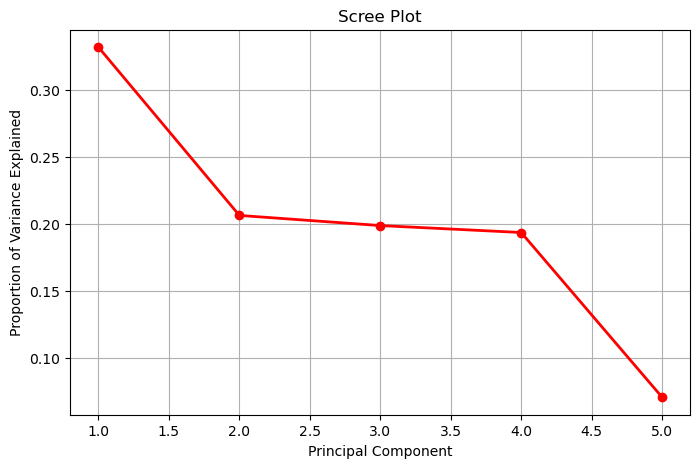

In [66]:
# Create a scree plot to determine optimal components
# 1. Assuming X is your dataset
#X_scaled = StandardScaler().fit_transform(X)
Final_Dataset_SVD_scaled = StandardScaler().fit_transform(Final_Dataset_SVD_array)

# 2. Fit PCA
pca = PCA()
pca.fit(Final_Dataset_SVD_scaled)

# 3. Plot the Scree Plot (Explained Variance Ratio)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.grid(True)
plt.show()


In [67]:
#Revised Data set with features odemeter and year
# 1. Select specific columns
Final_features = df_svd[['SVD_1', 'SVD_2','SVD_3']]


Final_features.head()

,SVD_1,SVD_2,SVD_3
0,2.192965,-2.556584,-0.607898
1,2.192965,-2.357785,-0.109303
2,2.192965,-0.767392,-0.156789
3,2.192965,-1.761388,-0.156789
4,2.192965,-0.568593,-0.154146


In [68]:
Final_features.columns = ['Odometer', 'Year','State']
Final_features.head()

,Odometer,Year,State
0,2.192965,-2.556584,-0.607898
1,2.192965,-2.357785,-0.109303
2,2.192965,-0.767392,-0.156789
3,2.192965,-1.761388,-0.156789
4,2.192965,-0.568593,-0.154146


In [69]:
regdata1 = Final_Dataset[['price','odometer','year','state_encoded']]
regdata1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51509 entries, 393517 to 397780
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          51509 non-null  int64  
 1   odometer       51509 non-null  Int64  
 2   year           51509 non-null  Int64  
 3   state_encoded  51509 non-null  float64
dtypes: Int64(2), float64(1), int64(1)
memory usage: 2.1 MB


In [70]:
regdata1.describe()

,price,odometer,year,state_encoded
count,51509.000000,51509.0,51509.0,51509.000000
mean,17676.950514,87430.670388,2012.860141,19826.348436
std,12718.199007,51332.531623,5.030254,12002.709142
min,1.000000,0.0,1995.0,12530.001732
25%,8200.000000,41908.0,2010.0,16050.705631
50%,14900.000000,88236.0,2014.0,17844.736102
75%,23995.000000,126563.0,2017.0,18771.652404
max,150000.000000,200000.0,2022.0,82486.162803


In [72]:
features = regdata1[["odometer"]]
price=regdata1["price"]
f=linear_model.LinearRegression(fit_intercept=False)
f.fit(features, price)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
#Add predictions to dataframe for plotting
regdata1["prediction"] = f.predict(features)

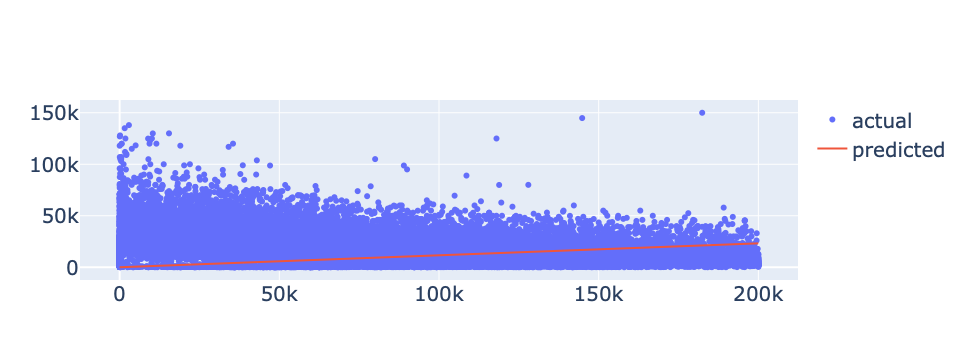

In [79]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=regdata1['odometer'],y=regdata1['price'],
                         mode="markers",name="actual"))
fig.add_trace(go.Scatter(x=regdata1['odometer'],y=regdata1['prediction'],
                         mode="lines",name="predicted"))
fig.update_layout(font_size=20)

In [80]:
f.predict([[100000]])

array([11605.15876058])

In [82]:
#need to use multi varialbe regression techniques and the data does not look linear so will you Polynomial feature select to predict
pfeatures = PolynomialFeatures(degree=2)
threefeatures=pfeatures.fit_transform(regdata1[['odometer','year','state_encoded']])
three_feature_poly_df=pd.DataFrame(threefeatures,columns=pfeatures.get_feature_names_out()).iloc[:,1:]
three_feature_poly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51509 entries, 0 to 51508
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   odometer                51509 non-null  float64
 1   year                    51509 non-null  float64
 2   state_encoded           51509 non-null  float64
 3   odometer^2              51509 non-null  float64
 4   odometer year           51509 non-null  float64
 5   odometer state_encoded  51509 non-null  float64
 6   year^2                  51509 non-null  float64
 7   year state_encoded      51509 non-null  float64
 8   state_encoded^2         51509 non-null  float64
dtypes: float64(9)
memory usage: 3.5 MB


In [83]:
#Create a pipline for efficient code
pipe = Pipeline([('quad_features',PolynomialFeatures(degree=2, include_bias=False)),('quad_model',LinearRegression())])

print(type(pipe))
print(pipe.named_steps)

<class 'sklearn.pipeline.Pipeline'>
{'quad_features': PolynomialFeatures(include_bias=False), 'quad_model': LinearRegression()}


In [85]:
#Fit the pipeline
X = regdata1[['odometer']]
y = regdata1['price']
pipe.fit(X,y)
quad_pipe_mse = float(mean_squared_error(y, pipe.predict(X)))

print(type(quad_pipe_mse))
print(quad_pipe_mse)
      

<class 'float'>
110802843.96852814


In [86]:
quad_reg = pipe.named_steps['quad_model']
coefs = quad_reg.coef_

print(coefs)

[-2.66854131e-01  7.31038734e-07]


In [89]:
pipelined_model = Pipeline([
    ('regdata_transform', PolynomialFeatures(degree=3, include_bias=False)),
    ('regdata_regression', LinearRegression())
])

pipelined_model.fit(regdata1[["odometer"]], regdata1["price"])



,steps,"[('regdata_transform', ...), ('regdata_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,False
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [90]:
#Test for overfitting by performing cross validation using k-fold and regularization using L1 and L2
model_predictions = {f'degree_{i}': None for i in range(1,11)}

for i in range(1, 11):
    pipe = Pipeline([('quad_features',PolynomialFeatures(degree=i, include_bias=False)),('quad_model',LinearRegression())])
    pipe.fit(X,y)
    preds = pipe.predict(X)
    model_predictions[f'degree_{i}'] = preds



model_predictions['degree_1'][:10]

array([2613.3894397, 2613.3894397, 2613.3894397, 2613.3894397,
       2613.3894397, 2613.3894397, 2613.3894397, 2613.3894397,
       2613.3894397, 2613.3894397])

In [91]:
model_predictions1 = {f'degree_{i}': None for i in range(1,11)}

for i in range(1, 11):
    pipe = Pipeline([('quad_features',PolynomialFeatures(degree=i, include_bias=False)),('quad_model',Ridge(alpha=0.0001))])
    pipe.fit(X,y)
    preds = pipe.predict(X)
    model_predictions[f'degree_{i}'] = preds



model_predictions['degree_1'][:10]

array([2613.3894397, 2613.3894397, 2613.3894397, 2613.3894397,
       2613.3894397, 2613.3894397, 2613.3894397, 2613.3894397,
       2613.3894397, 2613.3894397])

In [95]:
def get_MSE_for_degree_k_model(k):
    pipelined_model = Pipeline([
        ('regdata_transform', PolynomialFeatures(degree=k)),
        ('regdata_regression', LinearRegression(fit_intercept=True))
])
    pipelined_model.fit(regdata1[["odometer"]], regdata1["price"])
    return mean_squared_error(pipelined_model.predict(regdata1[["odometer"]]), regdata1 ["price"])

In [96]:

ks = np.array(range(0,7))
MSEs = [get_MSE_for_degree_k_model(k) for k in ks]
MSEs_and_k = pd.DataFrame({"k":ks, "MSE":MSEs})
MSEs_and_k.head()

,k,MSE
0,0,1.617494e+08
1,1,1.145657e+08
2,2,1.108028e+08
3,3,1.126123e+08
4,4,1.179333e+08


In [98]:
#Train Test Split
#Create dataset with all the X features (remove target y feature price)
#Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(regdata1.drop('price', axis = 1), np.log1p(regdata1.price), 
                                                   random_state=42, test_size = 0.3)


# Answer check
print(X_train.shape)
print(X_test.shape)

(36056, 4)
(15453, 4)


In [99]:
#Build Polynomial features
poly_features = PolynomialFeatures(degree = 3, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train[['odometer', 'year', 'state_encoded']])
X_test_poly = poly_features.transform(X_test[['odometer', 'year', 'state_encoded']])
columns = poly_features.get_feature_names_out()
train_df = pd.DataFrame(X_train_poly, columns=columns)
test_df = pd.DataFrame(X_test_poly, columns = columns)




test_df.to_csv('data/test_cubic1.csv', index = False)
train_df.to_csv('data/train_cubic1.csv', index = False)
# ANSWER CHECK
train_df.head()

,odometer,year,state_encoded,odometer^2,odometer year,odometer state_encoded,year^2,year state_encoded,state_encoded^2,odometer^3,odometer^2 year,odometer^2 state_encoded,odometer year^2,odometer year state_encoded,odometer state_encoded^2,year^3,year^2 state_encoded,year state_encoded^2,state_encoded^3
0,101479.0,2012.0,18997.989562,1.029799e+10,204175748.0,1.927897e+09,4048144.0,3.822395e+07,3.609236e+08,1.045029e+15,2.071955e+13,1.956411e+14,4.108016e+11,3.878929e+12,3.662617e+13,8.144866e+09,7.690660e+10,7.261783e+11,6.856823e+12
1,72000.0,2014.0,17046.479747,5.184000e+09,145008000.0,1.227347e+09,4056196.0,3.433161e+07,2.905825e+08,3.732480e+14,1.044058e+13,8.836895e+13,2.920461e+11,2.471876e+12,2.092194e+13,8.169179e+09,6.914386e+10,5.852331e+11,4.953408e+12
2,120350.0,2016.0,16697.744144,1.448412e+10,242625600.0,2.009574e+09,4064256.0,3.366265e+07,2.788147e+08,1.743164e+15,2.919999e+13,2.418522e+14,4.891332e+11,4.051300e+12,3.355534e+13,8.193540e+09,6.786391e+10,5.620904e+11,4.655576e+12
3,148350.0,2012.0,14371.480240,2.200772e+10,298480200.0,2.132009e+09,4048144.0,2.891542e+07,2.065394e+08,3.264846e+15,4.427954e+13,3.162835e+14,6.005422e+11,4.289602e+12,3.064013e+13,8.144866e+09,5.817782e+10,4.155574e+11,2.968278e+12
4,106244.0,2017.0,18997.989562,1.128779e+10,214294148.0,2.018422e+09,4068289.0,3.831894e+07,3.609236e+08,1.199260e+15,2.276747e+13,2.144453e+14,4.322313e+11,4.071158e+12,3.834597e+13,8.205739e+09,7.728931e+10,7.279829e+11,6.856823e+12


In [100]:
#SequentialFeatureSelector
selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=3)
best_features = selector.fit_transform(train_df, y_train)
best_features_df = pd.DataFrame(best_features, columns = selector.get_feature_names_out())


# ANSWER CHECK
best_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36056 entries, 0 to 36055
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   odometer         36056 non-null  float64
 1   odometer year^2  36056 non-null  float64
 2   year^3           36056 non-null  float64
dtypes: float64(3)
memory usage: 845.2 KB


In [101]:
backward_selector = SequentialFeatureSelector(LinearRegression(), 
                                              n_features_to_select=3,
                                              direction = 'backward')

In [102]:
#Pipeline for regression model
pipe = Pipeline([('column_selector', selector),
                ('linreg', LinearRegression())])
pipe.fit(train_df, y_train)
train_preds = pipe.predict(train_df)
test_preds = pipe.predict(test_df)
train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)


# Answer check
print(f'Train MSE: {train_mse: .2f}')
print(f'Test MSE: {test_mse: .2f}')
pipe

Train MSE:  0.70
Test MSE:  0.72


,steps,"[('column_selector', ...), ('linreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,estimator,LinearRegression()
,n_features_to_select,3
,tol,None
,direction,'forward'
,scoring,None
,cv,5
,n_jobs,None


In [103]:
#Backward Selection
backward_pipe = Pipeline([('column_selector', backward_selector),
                ('linreg', LinearRegression())])
backward_pipe.fit(train_df, y_train)
train_preds1 = backward_pipe.predict(train_df)
test_preds1 = backward_pipe.predict(test_df)
backward_train_mse = mean_squared_error(y_train, train_preds)
backward_test_mse = mean_squared_error(y_test, test_preds)


# Answer check
print(f'Train MSE: {backward_train_mse: .2f}')
print(f'Test MSE: {backward_test_mse: .2f}')
backward_pipe

Train MSE:  0.70
Test MSE:  0.72


,steps,"[('column_selector', ...), ('linreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,estimator,LinearRegression()
,n_features_to_select,3
,tol,None
,direction,'backward'
,scoring,None
,cv,5
,n_jobs,None


In [104]:
#Try different models to improve on Error score i.e. Ridge...

ridge_low_pipe = Pipeline([('column_selector', selector),
                ('ridge_low', Ridge(alpha = 0.1))])
ridge_low_pipe.fit(train_df, y_train)
ridge_train_low_preds = ridge_low_pipe.predict(train_df)
train_ridge_mse = mean_squared_error(y_train, ridge_train_low_preds)


# Answer check
ridge_low_pipe
print(f'Train MSE: {train_mse: .2f}')

Train MSE:  0.70


In [105]:
#Try different models to improve on Error score i.e. Ridge...
ridge_high_pipe = Pipeline([('column_selector', selector),
                ('ridge_high', Ridge(alpha = 1000))])
ridge_high_pipe.fit(train_df, y_train)
ridge_train_high_preds = ridge_high_pipe.predict(train_df)
train_ridge_mse = mean_squared_error(y_train, ridge_train_high_preds)


# Answer check
ridge_low_pipe
print(f'Train MSE: {train_mse: .2f}')

Train MSE:  0.70


In [106]:
#There does not seem to be a difference between my Lindar and Ridge training models as they have the same error score (MSE)


In [107]:
#Ridge Optimal based on GridSerachCV
ridge_high_pipe = Pipeline([('column_selector', selector),
                ('ridge_high', Ridge(alpha = 10))])
ridge_high_pipe.fit(train_df, y_train)
ridge_train_high_preds = ridge_high_pipe.predict(train_df)
train_ridge_mse = mean_squared_error(y_train, ridge_train_high_preds)


# Answer check
ridge_low_pipe
print(f'Train MSE: {train_mse: .2f}')

Train MSE:  0.70


In [108]:
#Data may need to be scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(scaler.mean_)
print('----------')
print(scaler.scale_)

[87252.33090193  2012.87763479 19820.67158118 10125.77152347]
----------
[5.12886854e+04 5.03026707e+00 1.19951077e+04 5.95213336e+03]


In [109]:
#Use scaled data in pipe
scaled_pipe = Pipeline([
    
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
]).fit(X_train, y_train)


train_preds_scaled = scaled_pipe.predict(X_train)
test_preds_scaled = scaled_pipe.predict(X_test)
train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)
### END SOLUTION

# Answer check
print(f'Train MSE: {train_mse}')
print(f'Test MSE: {test_mse}')

Train MSE: 0.704289681713651
Test MSE: 0.7237314558536316


In [110]:
#Scaled data has higher MSE

In [111]:
#Perform GridSearchCV to determine optimal alfpha for Ridge Regression
#Dictionary for Grid Search
params_dict = {'alpha': [0.1, 1.0, 10.0]}


# Answer check
print(params_dict.values())
print(params_dict.keys())

dict_values([[0.1, 1.0, 10.0]])
dict_keys(['alpha'])


In [112]:
#Creating Grid Search Object
ridge = Ridge()
grid = GridSearchCV(ridge, param_grid=params_dict)


# Answer check
print(grid.get_params()['param_grid'])
print(grid)

{'alpha': [0.1, 1.0, 10.0]}
GridSearchCV(estimator=Ridge(), param_grid={'alpha': [0.1, 1.0, 10.0]})


In [113]:
#Performing the Grid Search
ridge = Ridge()
grid = GridSearchCV(ridge, param_grid=params_dict)
grid.fit(X_train, y_train)
train_preds_grid = grid.predict(X_train)
test_preds_grid = grid.predict(X_test)
train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)

# Answer check
print(f'Train MSE: {train_mse}')
print(f'Test MSE: {test_mse}')

Train MSE: 0.704289681713651
Test MSE: 0.7237314558536316


In [114]:
#Identify optimal alpha value
ridge = Ridge()
grid = GridSearchCV(ridge, param_grid=params_dict)
grid.fit(X_train, y_train)
best_alpha = grid.best_params_


# Answer check
print(f'Best alpha: {list(best_alpha.values())[0]}')

Best alpha: 10.0


In [115]:
#Pipeline with grid searh
pipe = Pipeline([('scale', StandardScaler()), ('ridge', Ridge())])

In [116]:
param_dict = {'ridge__alpha': [0.001, 0.1, 1.0, 10.0, 100.0, 1000.0]}

In [117]:
grid_2 = GridSearchCV(pipe, param_grid=param_dict)
grid_2.fit(X_train, y_train)
train_preds = grid_2.predict(X_train)
test_preds = grid_2.predict(X_test)
model_2_train_mse = mean_squared_error(y_train, train_preds)
model_2_test_mse = mean_squared_error(y_test, test_preds)
model_2_best_alpha = grid_2.best_params_


# Answer check
print(f'Test MSE: {model_2_test_mse}')
print(f'Best Alpha: {list(model_2_best_alpha.values())[0]}')

Test MSE: 0.7234501632235313
Best Alpha: 10.0


In [118]:
#Last model to check LASSO
lasso_pipe = ''
lasso_coefs = ''

### BEGIN SOLUTION
lasso_pipe = Pipeline([('polyfeatures', PolynomialFeatures(degree = 3, include_bias = False)),
                      ('scaler', StandardScaler()),
                     ('lasso', Lasso(random_state = 42))])
lasso_pipe.fit(X_train, y_train)
lasso_coefs = lasso_pipe.named_steps['lasso'].coef_
### END SOLUTION

# Answer check
print(type(lasso_coefs))
print(lasso_coefs)
lasso_pipe

<class 'numpy.ndarray'>
[-0.  0.  0. -0. -0. -0. -0. -0.  0.  0. -0. -0. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0. -0. -0.  0.  0. -0. -0. -0. -0. -0. -0. -0. -0.]


,steps,"[('polyfeatures', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [119]:
lasso_train_mse = ''
lasso_test_mse = ''

### BEGIN SOLUTION
lasso_train_mse = mean_squared_error(y_train, lasso_pipe.predict(X_train))
lasso_test_mse = mean_squared_error(y_test, lasso_pipe.predict(X_test))
### END SOLUTION

# Answer check
print(lasso_train_mse)
print(lasso_test_mse)

0.9081619851116065
0.9366825672347959


In [160]:
#lasso has the highest error

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [120]:
#Through data analysis and data modeling I was able to complete feature selection and choose the first 3 components below were principal components of the 5 numeric data fields I hypothesized to have the biggest incluence on pricing make up 90% of the variance as determined through Singular Value Decomposition(SVD) and as visualized by the below scree plot 
#1 Odometer
#2 Year
#3 State
#4 Condition
#5 Manufacturer

#Determine the number of Principle Components derived from the SVD exercise
num_princ_comp = int((np.cumsum(percent_variance_explained) < .90).sum())
num_princ_comp

#The first three components odemeter, ,year and state drive 90% of the variance and should be used going forward in the predictive model

3

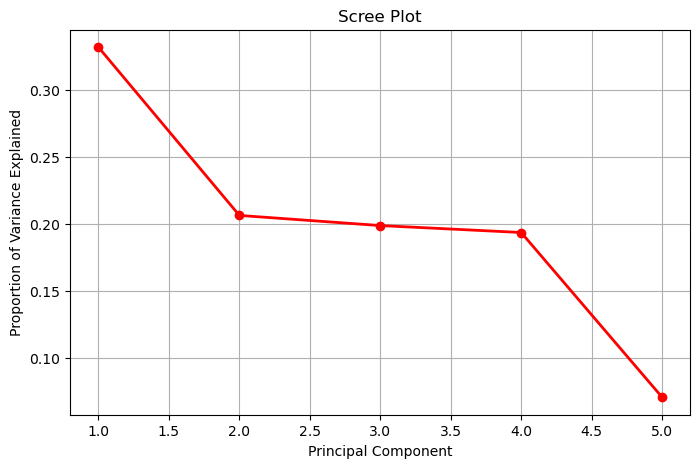

In [121]:
# Create a scree plot to determine optimal components
# 1. Assuming X is your dataset
#X_scaled = StandardScaler().fit_transform(X)
Final_Dataset_SVD_scaled = StandardScaler().fit_transform(Final_Dataset_SVD_array)

# 2. Fit PCA
pca = PCA()
pca.fit(Final_Dataset_SVD_scaled)

# 3. Plot the Scree Plot (Explained Variance Ratio)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.grid(True)
plt.show()


In [122]:
#Then I split my data set 70/30 in order to validate a training dataset and test data set using Train Test Split
#X_train, X_test, y_train, y_test = train_test_split(regdata.drop('price', axis = 1), np.log1p(regdata.price), 
#                                                   random_state=42, test_size = 0.3)

In [126]:
#Now that I know my principal features I started building polynomial features of the the three principal features and 
poly_features = PolynomialFeatures(degree = 3, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train[['odometer', 'year', 'state_encoded']])
X_test_poly = poly_features.transform(X_test[['odometer', 'year', 'state_encoded']])
columns = poly_features.get_feature_names_out()
train_df = pd.DataFrame(X_train_poly, columns=columns)
test_df = pd.DataFrame(X_test_poly, columns = columns)




test_df.to_csv('data/test_cubic1.csv', index = False)
train_df.to_csv('data/train_cubic1.csv', index = False)
# ANSWER CHECK
train_df.head()



,odometer,year,state_encoded,odometer^2,odometer year,odometer state_encoded,year^2,year state_encoded,state_encoded^2,odometer^3,odometer^2 year,odometer^2 state_encoded,odometer year^2,odometer year state_encoded,odometer state_encoded^2,year^3,year^2 state_encoded,year state_encoded^2,state_encoded^3
0,101479.0,2012.0,18997.989562,1.029799e+10,204175748.0,1.927897e+09,4048144.0,3.822395e+07,3.609236e+08,1.045029e+15,2.071955e+13,1.956411e+14,4.108016e+11,3.878929e+12,3.662617e+13,8.144866e+09,7.690660e+10,7.261783e+11,6.856823e+12
1,72000.0,2014.0,17046.479747,5.184000e+09,145008000.0,1.227347e+09,4056196.0,3.433161e+07,2.905825e+08,3.732480e+14,1.044058e+13,8.836895e+13,2.920461e+11,2.471876e+12,2.092194e+13,8.169179e+09,6.914386e+10,5.852331e+11,4.953408e+12
2,120350.0,2016.0,16697.744144,1.448412e+10,242625600.0,2.009574e+09,4064256.0,3.366265e+07,2.788147e+08,1.743164e+15,2.919999e+13,2.418522e+14,4.891332e+11,4.051300e+12,3.355534e+13,8.193540e+09,6.786391e+10,5.620904e+11,4.655576e+12
3,148350.0,2012.0,14371.480240,2.200772e+10,298480200.0,2.132009e+09,4048144.0,2.891542e+07,2.065394e+08,3.264846e+15,4.427954e+13,3.162835e+14,6.005422e+11,4.289602e+12,3.064013e+13,8.144866e+09,5.817782e+10,4.155574e+11,2.968278e+12
4,106244.0,2017.0,18997.989562,1.128779e+10,214294148.0,2.018422e+09,4068289.0,3.831894e+07,3.609236e+08,1.199260e+15,2.276747e+13,2.144453e+14,4.322313e+11,4.071158e+12,3.834597e+13,8.205739e+09,7.728931e+10,7.279829e+11,6.856823e+12


In [124]:
#Then I used SequentialFeatureSelector best features technique to pick the optimal number and mix of features

selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=3)
best_features = selector.fit_transform(train_df, y_train)
best_features_df = pd.DataFrame(best_features, columns = selector.get_feature_names_out())


# ANSWER CHECK
best_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36056 entries, 0 to 36055
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   odometer         36056 non-null  float64
 1   odometer year^2  36056 non-null  float64
 2   year^3           36056 non-null  float64
dtypes: float64(3)
memory usage: 845.2 KB


In [127]:
#Then I fit and trained various models on my training data to determine which model would yield the best future predictions by comparing their error scores (MSE)
#I used linear regression, Ridge regression, and Lasso regression and found linear and ridge regression to have the lowest error

pipe = Pipeline([('column_selector', selector),
                ('linreg', LinearRegression())])
pipe.fit(train_df, y_train)
train_preds = pipe.predict(train_df)
test_preds = pipe.predict(test_df)
train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)


# Answer check
print(f'Train MSE: {train_mse: .2f}')
print(f'Test MSE: {test_mse: .2f}')
pipe

Train MSE:  0.70
Test MSE:  0.72


,steps,"[('column_selector', ...), ('linreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,estimator,LinearRegression()
,n_features_to_select,3
,tol,None
,direction,'forward'
,scoring,None
,cv,5
,n_jobs,None


In [132]:

# Extract coefficients
coefficients = pipe.named_steps['linreg'].coef_
# Extract intercept
intercept = pipe.named_steps['linreg'].intercept_

print("Coefficients:", coefficients)
print("Intercept:", intercept)

Coefficients: [-1.34856376e-04  3.23342771e-11  3.90345656e-09]
Intercept: -21.997615107418838


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [133]:
#Used Motor America LLC., you had reached out to BP ML Consulting in order to determine what drives the pricing of a car.  My team was able collect US used car sales data and through data analysis and modeling we were able to create a machine learning model which predicts pricing on used vehicles given attributes that are the most highly sought after in the United States.  
#In our findings we have concluded that Odometer, year and state are the biggest drivers of price.
#Based on our model the odometer is the biggest driver of price and has a negative correlation meaning that as odometer goes up the price goes down.
#Both year and state are positively correlated where the higher the year the higher the price and certain states have higer average pricing like California.
#
#Final recomendation and next steps is for Used Motor America LLC. to use the model on newer data to test the accuracy and also make some potential purchases on the predicted pricing. For example if the model predicts a price of the car to be $10,000 and the actural price is $5000 then they should purchase the car in order to maximize profits.
#As a next step we should continue to feed the model new data in order to improve on the accuracy since the errors on both the training and test data are still quite high.
#As an enhancment to the model we should pull in some resale data and possibly predict profit and margins.

